<a href="https://colab.research.google.com/github/Sakshambh09/CN-NLP_Lab/blob/main/SakshamBhardwaj_500121198_CN_NLP_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment 1: Data Analysis & Visualization**

**NAME:** Saksham Bhardwaj

**SAP ID:** 500121198

**Roll No. :** R2142231948

**Batch:** AIML B1

**Initial Setup & Data Loading**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load dataset
df = pd.read_csv("employee_information_100.csv")
print("Dataset Head:")
print(df.head())

Dataset Head:
  Employee_ID    Name  Department  Age  Gender  Salary  Experience_Years
0        E001  Diana1          HR   39    Male   58000                 8
1        E002  Diana2  Operations   56    Male  105000                27
2        E003    Bob3          HR   27    Male   59000                32
3        E004   Neha4          HR   57    Male  113000                34
4        E005  Nisha5          IT   50  Female   30000                10


**Experiment 1.1: Average Salary by Department**

**Question:** Read the employee dataset and display the average salary of each department using a bar chart

/tmp/ipykernel_2705/1285538850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_salary_dept, x="Department", y="Salary", palette="Blues_d")


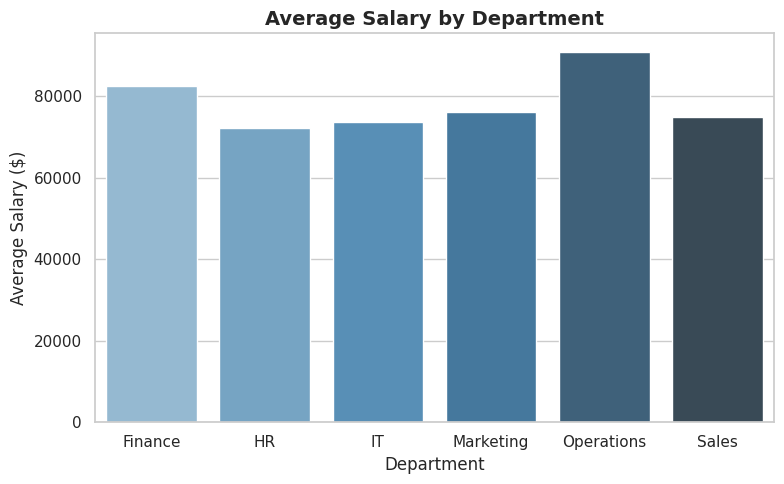

   Department        Salary
0     Finance  82416.666667
1          HR  72095.238095
2          IT  73611.111111
3   Marketing  76100.000000
4  Operations  90875.000000
5       Sales  74769.230769


In [ ]:
# Aggregation
avg_salary_dept = df.groupby("Department")["Salary"].mean().reset_index()

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_salary_dept, x="Department", y="Salary", palette="Blues_d")
plt.title("Average Salary by Department", fontsize=14, fontweight="bold")
plt.xlabel("Department", fontsize=12)
plt.ylabel("Average Salary ($)", fontsize=12)
plt.tight_layout()
plt.show()

print(avg_salary_dept)

**Experiment 1.2: Employee Count per Department**

**Question:** Display the number of employees working in each department.  

In [ ]:
# Compute employee distribution
dept_counts = df["Department"].value_counts().reset_index()
dept_counts.columns = ["Department", "Employee Count"]

# Display formatted table
print("Employee Count per Department:")
print(dept_counts.to_string(index=False))

Employee Count per Department:
Department  Employee Count
        HR              21
 Marketing              20
        IT              18
Operations              16
     Sales              13
   Finance              12


**Experiment 1.3: Gender Distribution Pie Chart**

**Question:** Display the percentage of male and female employees using a pie chart.  

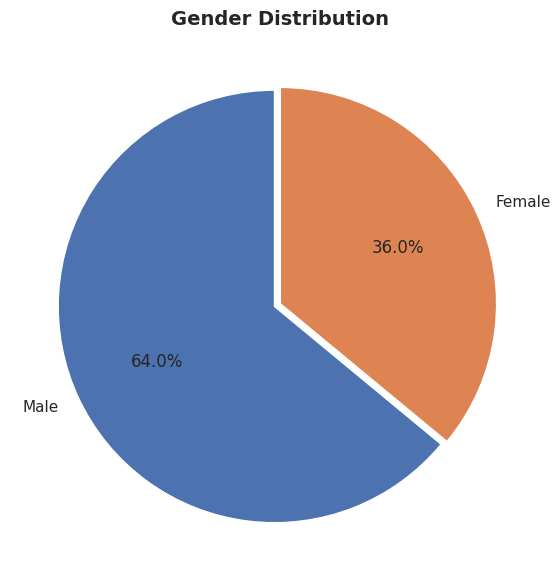

In [ ]:
# Compute frequency
gender_counts = df["Gender"].value_counts()

# Visualization
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
    explode=(0.03, 0)
)
plt.title("Gender Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Experiment 1.4: Salary Distribution Histogram**

**Question:** Draw a histogram showing salary distribution.

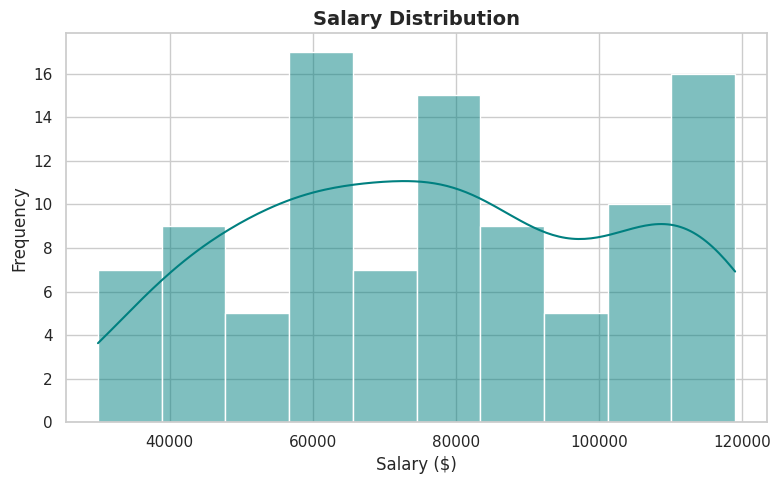

In [ ]:
# Visualization
plt.figure(figsize=(8, 5))
sns.histplot(df["Salary"], kde=True, bins=10, color="teal")
plt.title("Salary Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Salary ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

**Experiment 1.5: Experience vs. Salary Scatter Plot**

**Question:** Draw a scatter plot showing the relationship between experience and salary.

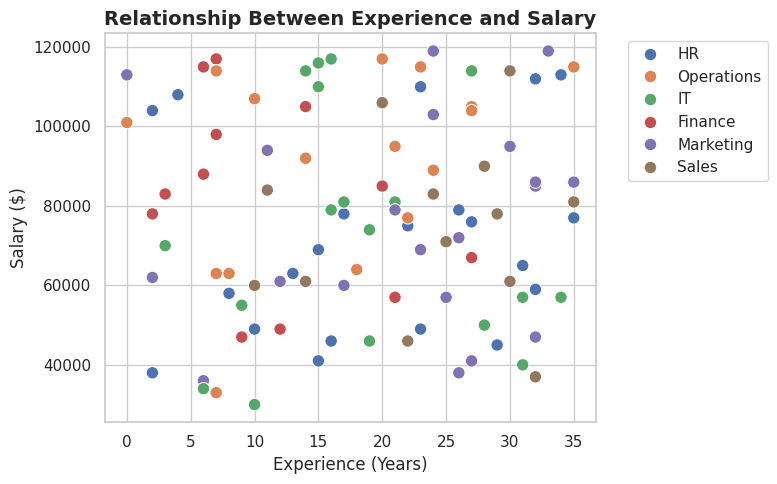

In [ ]:
# Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Experience_Years", y="Salary", hue="Department", s=80)
plt.title("Relationship Between Experience and Salary", fontsize=14, fontweight="bold")
plt.xlabel("Experience (Years)", fontsize=12)
plt.ylabel("Salary ($)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Experiment 1.6: Top 10 Highest-Paid Employees**

**Question:** Display the top 10 employees with the highest salary.  

In [ ]:
# Extract top 10 rows
top_10_paid = df.nlargest(10, "Salary")[["Employee_ID", "Name", "Department", "Salary"]]

print("Top 10 Highest Paid Employees:")
print(top_10_paid.to_string(index=False))

Top 10 Highest Paid Employees:
Employee_ID      Name Department  Salary
       E086    Omar86  Marketing  119000
       E088   Diana88  Marketing  119000
       E015   Ishan15 Operations  117000
       E023   Rahul23    Finance  117000
       E059    Neha59         IT  117000
       E049 Charlie49         IT  116000
       E032  George32 Operations  115000
       E056   Sneha56 Operations  115000
       E065     Bob65    Finance  115000
       E010  Vikram10         IT  114000


**Experiment 1.7: Maximum Salary per Department**

**Question:** Find the highest salary in every department.

In [ ]:
# Grouping aggregation
max_salary_dept = df.groupby("Department")["Salary"].max().reset_index()
max_salary_dept.columns = ["Department", "Maximum Salary"]

print("Highest Salary in Each Department:")
print(max_salary_dept.to_string(index=False))

Highest Salary in Each Department:
Department  Maximum Salary
   Finance          117000
        HR          113000
        IT          117000
 Marketing          119000
Operations          117000
     Sales          114000


**Experiment 1.8: Above-Average Salary Filter**


**Question:** Display employees whose salary is greater than the overall average salary.

In [ ]:
# Compute global mean
overall_avg_salary = df["Salary"].mean()

# Boolean index filtering
above_avg_employees = df[df["Salary"] > overall_avg_salary]

print(f"Overall Average Salary: ${overall_avg_salary:.2f}")
print(f"Total Employees Above Average: {len(above_avg_employees)}\n")
print(above_avg_employees[["Employee_ID", "Name", "Department", "Salary"]].head(10).to_string(index=False))

Overall Average Salary: $77760.00
Total Employees Above Average: 51

Employee_ID     Name Department  Salary
       E002   Diana2 Operations  105000
       E004    Neha4         HR  113000
       E008    Neha8    Finance   98000
       E009   Mohan9         HR  110000
       E010 Vikram10         IT  114000
       E011  Julia11         HR   78000
       E013 George13 Operations  107000
       E014  Sneha14 Operations   89000
       E015  Ishan15 Operations  117000
       E016    Bob16         IT   81000


**Experiment 1.9: Average Experience by Department**


**Question:** Calculate the average years of experience in each department.  

In [ ]:
# Grouped mean calculation
avg_exp_dept = df.groupby("Department")["Experience_Years"].mean().reset_index()
avg_exp_dept.columns = ["Department", "Average Experience (Years)"]
avg_exp_dept["Average Experience (Years)"] = avg_exp_dept["Average Experience (Years)"].round(2)

print("Average Experience per Department:")
print(avg_exp_dept.to_string(index=False))

Average Experience per Department:
Department  Average Experience (Years)
   Finance                       11.17
        HR                       19.81
        IT                       18.39
 Marketing                       21.90
Operations                       16.88
     Sales                       23.85


**Experiment 1.10: Age Distribution Histogram**

**Question:** Display the distribution of employee ages using a histogram.

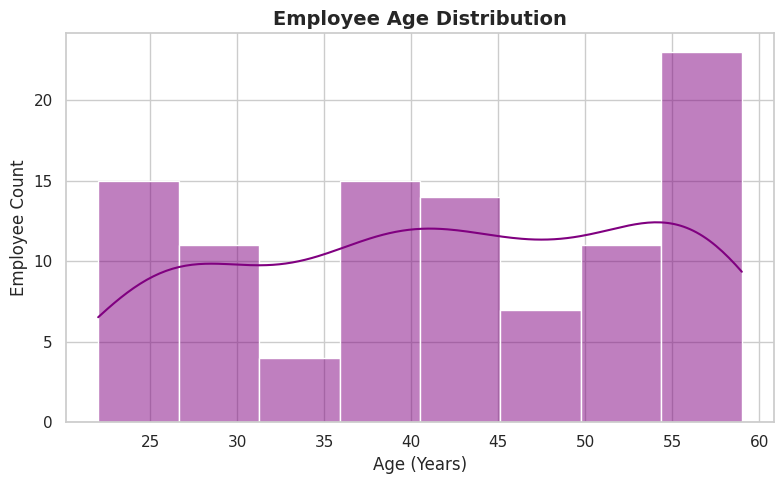

In [ ]:
# Visualization
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], kde=True, bins=8, color="purple")
plt.title("Employee Age Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Employee Count", fontsize=12)
plt.tight_layout()
plt.show()